

---


# Credit Approval

---
This dataset concerns credit card applications.  All attribute names and values have been changed to meaningless symbols to protect confidentiality of the data.







In [2]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data Pre-Processing

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
import joblib
import matplotlib.pyplot as plt

# Set random seed
np.random.seed(42)

# 1. Data Loading
url = "/content/drive/MyDrive/City_University /Year1/Neural_Networks/Indivisual_Final_cw/crx.data"
columns = ['Gender','Age','Debt','Marital Status','Education Level','Occupation','Employer','Years Employed','Prior Default','Employed','Credit Score','Citizen','Type of Housing','Savings','Current Balance','Approval']
data = pd.read_csv(url, names=columns, na_values='?')

# Minimal cleaning
data = data.dropna()
data['Approval'] = data['Approval'].map({'+': 1, '-': 0})
for col in data.select_dtypes(include=['object']).columns:
    data[col] = pd.factorize(data[col])[0]


# Split Train test data
X = data.drop('Approval', axis=1)
y = data['Approval']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Display the first few rows to check the content
print(data.head())

   Gender    Age   Debt  Marital Status  Education Level  Occupation  \
0       0  30.83  0.000               0                0           0   
1       1  58.67  4.460               0                0           1   
2       1  24.50  0.500               0                0           1   
3       0  27.83  1.540               0                0           0   
4       0  20.17  5.625               0                0           0   

   Employer  Years Employed  Prior Default  Employed  Credit Score  Citizen  \
0         0            1.25              0         0             1        0   
1         1            3.04              0         0             6        0   
2         1            1.50              0         1             0        0   
3         0            3.75              0         0             5        1   
4         0            1.71              0         1             0        0   

   Type of Housing  Savings  Current Balance  Approval  
0                0    202.0        

In [3]:
data.shape

(653, 16)

### Statistic Summary of the dataset

In [4]:
def create_summary_table(df, features, class_col):
    summary = []
    for feature in features:
        approved = df[df[class_col] == 1][feature]
        denied = df[df[class_col] == 0][feature]

        summary.append({
            'Feature': feature,
            'Approved Mean': approved.mean(),
            'Approved Std': approved.std(),
            'Approved Min': approved.min(),
            'Approved Max': approved.max(),
            'Denied Mean': denied.mean(),
            'Denied Std': denied.std(),
            'Denied Min': denied.min(),
            'Denied Max': denied.max()
        })
    return pd.DataFrame(summary)

# Use only numerical features (excluding 'Approval')
numerical_features = ['Age', 'Debt', 'Years Employed', 'Credit Score', 'Savings', 'Current Balance']


summary_table = create_summary_table(data, numerical_features, 'Approval')
print(summary_table.round(2))

           Feature  Approved Mean  Approved Std  Approved Min  Approved Max  \
0              Age          33.85         12.69         13.75         76.75   
1             Debt           5.97          5.49          0.00         28.00   
2   Years Employed           3.48          4.17          0.00         28.50   
3     Credit Score           4.72          6.40          0.00         67.00   
4          Savings         164.62        162.54          0.00        840.00   
5  Current Balance        2009.73       7660.95          0.00     100000.00   

   Denied Mean  Denied Std  Denied Min  Denied Max  
0        29.56       10.72       15.17       74.83  
1         3.88        4.39        0.00       26.34  
2         1.22        2.03        0.00       13.88  
3         0.67        1.96        0.00       20.00  
4       193.41      172.06        0.00     2000.00  
5       187.97      632.78        0.00     5552.00  


### Pairwise Comparison for Main Features

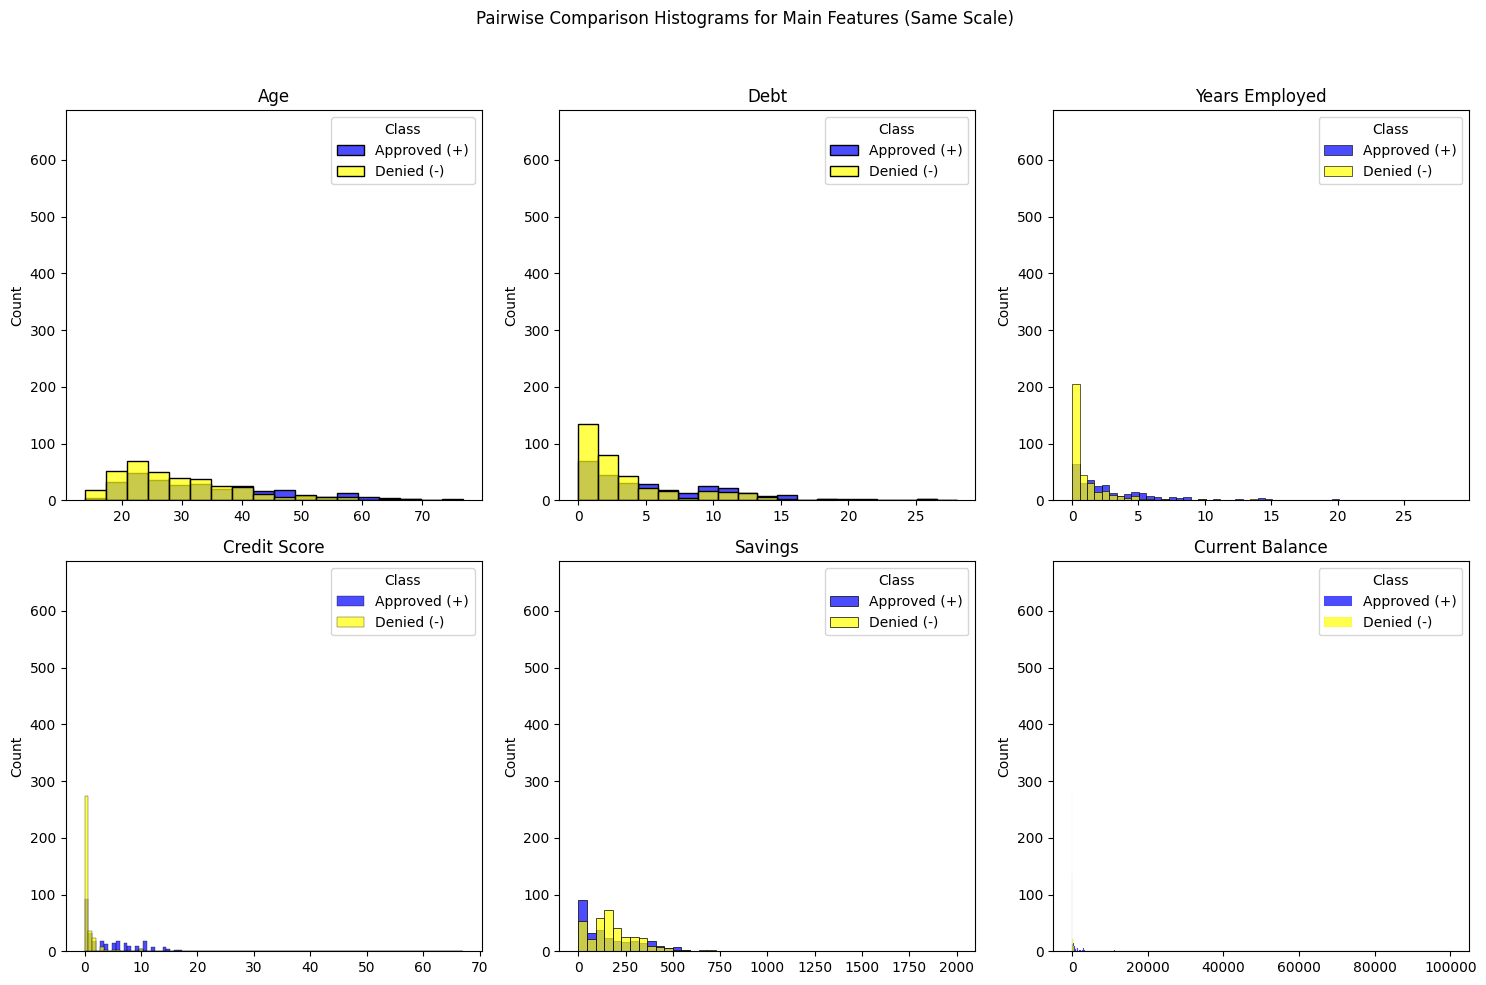

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['Age', 'Debt', 'Years Employed', 'Credit Score', 'Savings', 'Current Balance']

# Max count across all histograms
max_count = 0
for feature in features:
    counts, _ = np.histogram(data[feature], bins=20)
    if counts.max() > max_count:
        max_count = counts.max()

# Plot with shared y-axis limit
plt.figure(figsize=(15, 10))

for i, feature in enumerate(features):
    plt.subplot(2, 3, i+1)
    sns.histplot(
        data=data,
        x=feature,
        hue='Approval',
        palette={1: 'blue', 0: 'yellow'},
        alpha=0.7
    )
    plt.title(feature)
    plt.xlabel('')
    plt.ylabel('Count')
    plt.ylim(0, max_count * 1.1)  # Adding a small margin above the max
    plt.legend(title='Class', labels=['Approved (+)', 'Denied (-)'])

plt.suptitle('Pairwise Comparison Histograms for Main Features (Same Scale)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [5]:
from sklearn.model_selection import train_test_split

X = data.drop('Approval', axis=1)
y = data['Approval']

# Perform train-test split (80% training data, 20% testing data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shape of the splits
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (522, 15)
Test data shape: (131, 15)


### Checking Missing Values

In [6]:
# Check for missing values
missing_values = data.isnull().sum()
print("Missing values per column:\n", missing_values)

# Percentage of missing values
print("\nMissing value percentage:")
print((data.isnull().sum() / len(data)) * 100)

Missing values per column:
 Gender             0
Age                0
Debt               0
Marital Status     0
Education Level    0
Occupation         0
Employer           0
Years Employed     0
Prior Default      0
Employed           0
Credit Score       0
Citizen            0
Type of Housing    0
Savings            0
Current Balance    0
Approval           0
dtype: int64

Missing value percentage:
Gender             0.0
Age                0.0
Debt               0.0
Marital Status     0.0
Education Level    0.0
Occupation         0.0
Employer           0.0
Years Employed     0.0
Prior Default      0.0
Employed           0.0
Credit Score       0.0
Citizen            0.0
Type of Housing    0.0
Savings            0.0
Current Balance    0.0
Approval           0.0
dtype: float64


## Feature Distribution

We plotted the feature distributions to visually inspect the spread, detect skewness, and identify potential outliers in each feature — helping us decide if transformations were needed.

Plotting feature distributions BEFORE transformation...


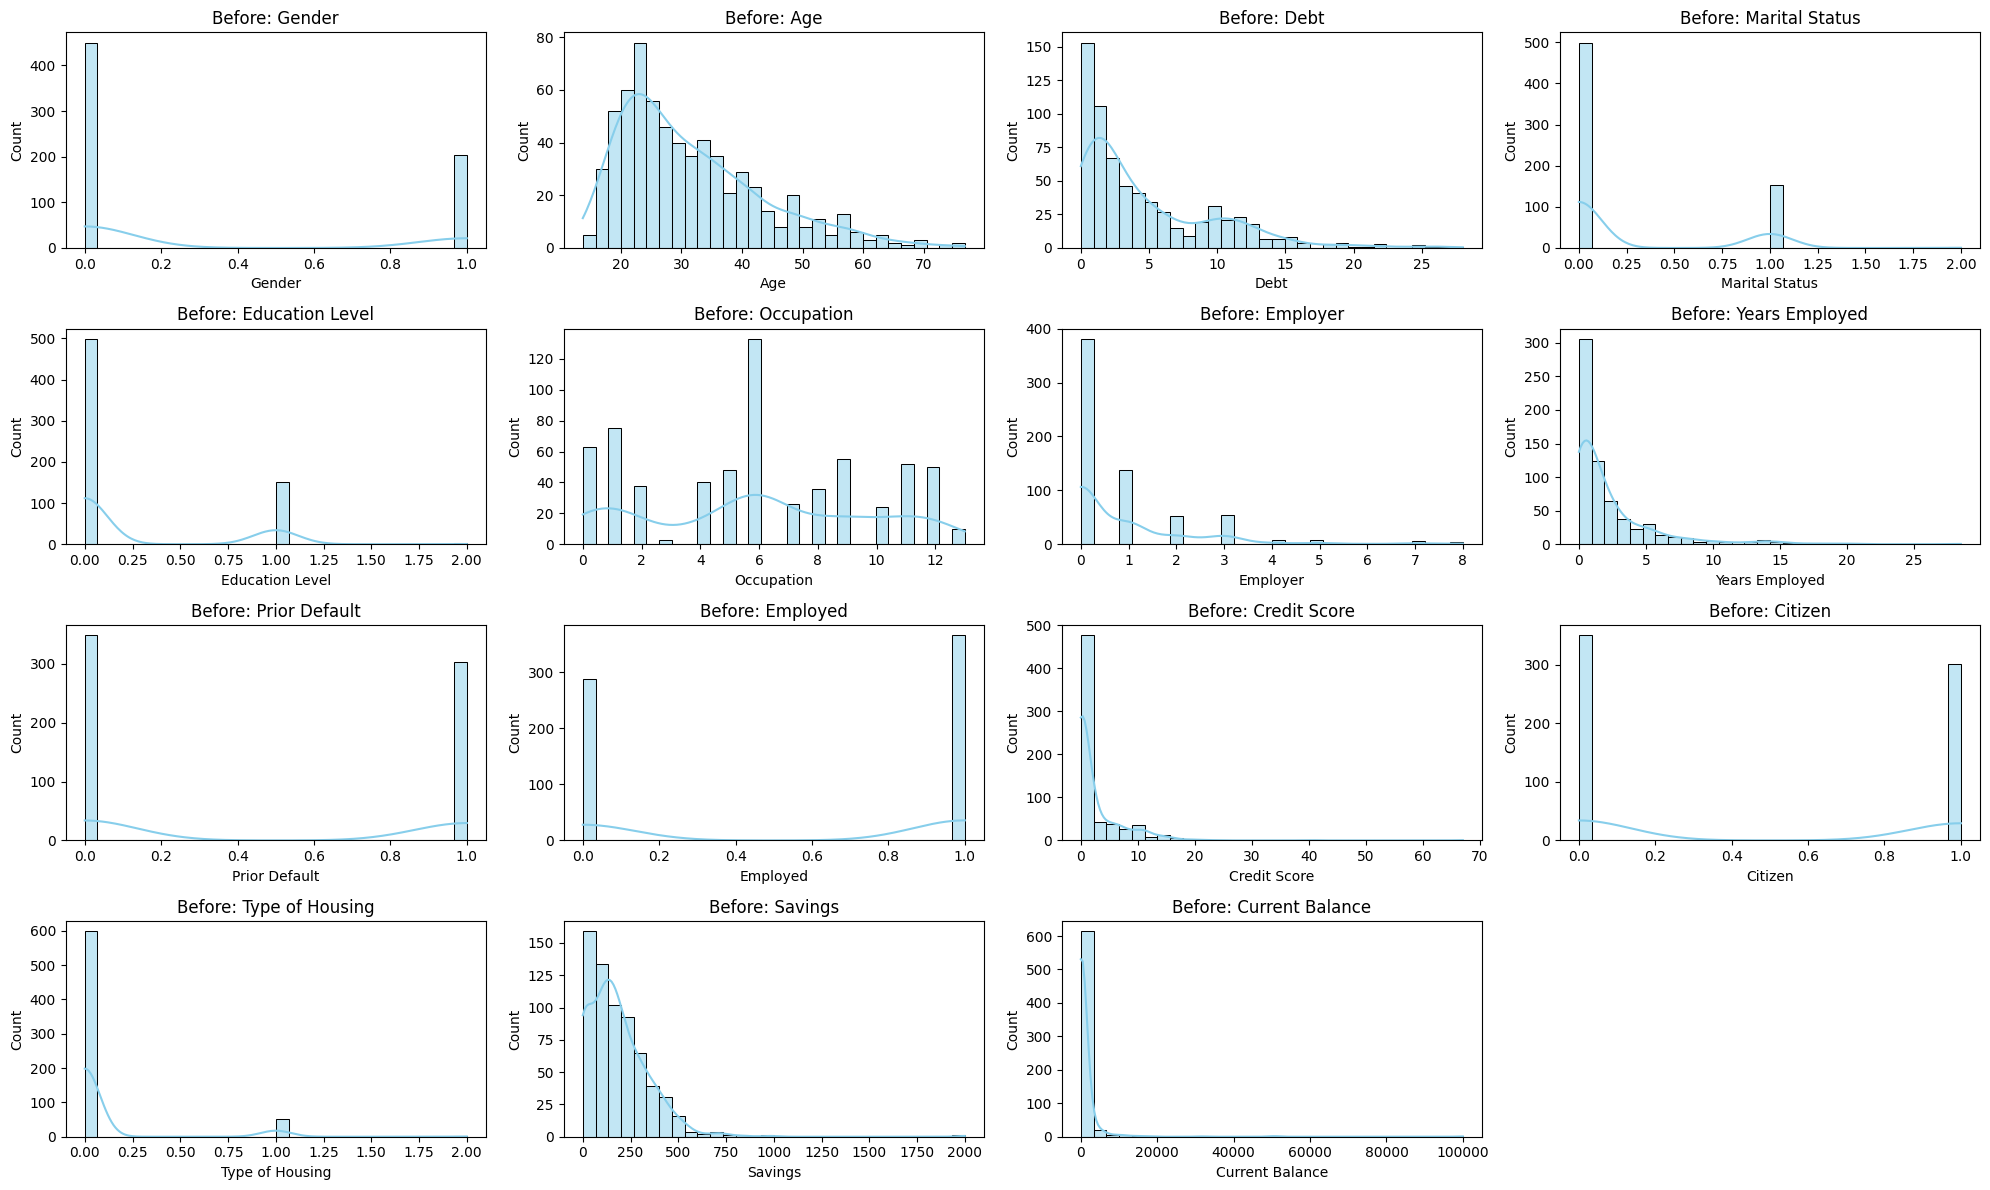

<ipython-input-7-9321be07587d>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=skew_df_before, x='Skewness', y='Feature', palette='coolwarm')


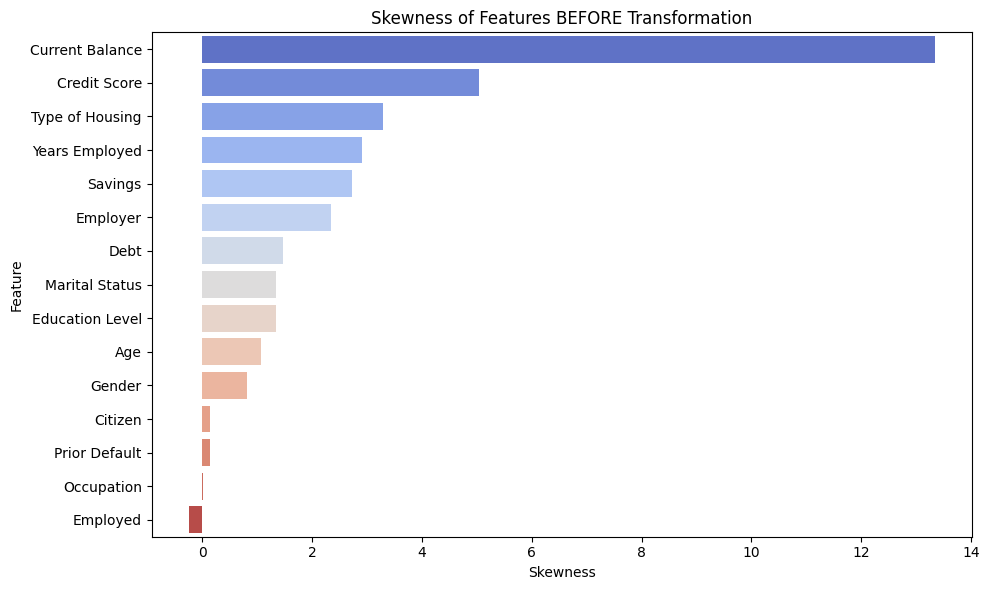

Plotting feature distributions AFTER transformation...


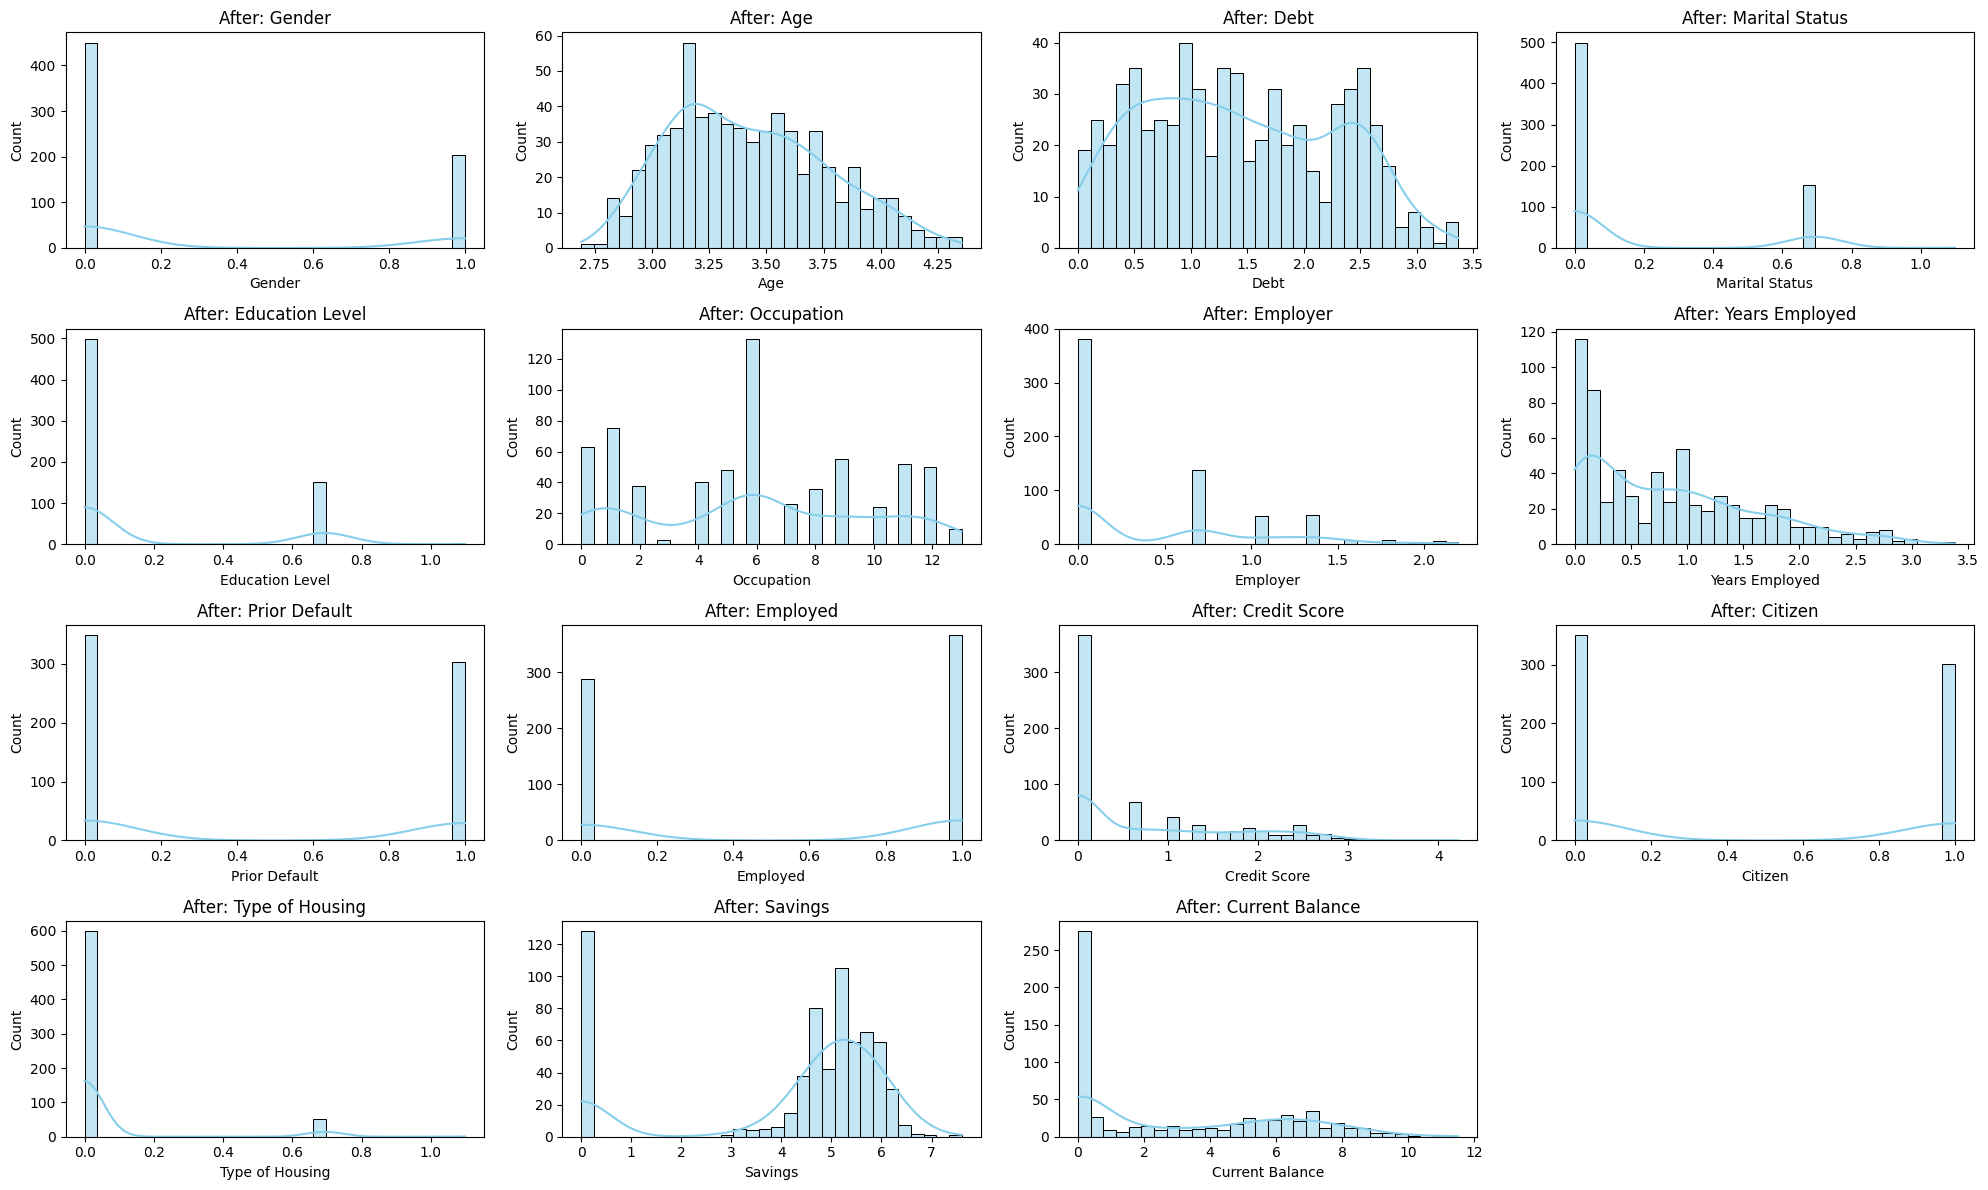

<ipython-input-7-9321be07587d>:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=skew_df_after, x='Skewness', y='Feature', palette='viridis')


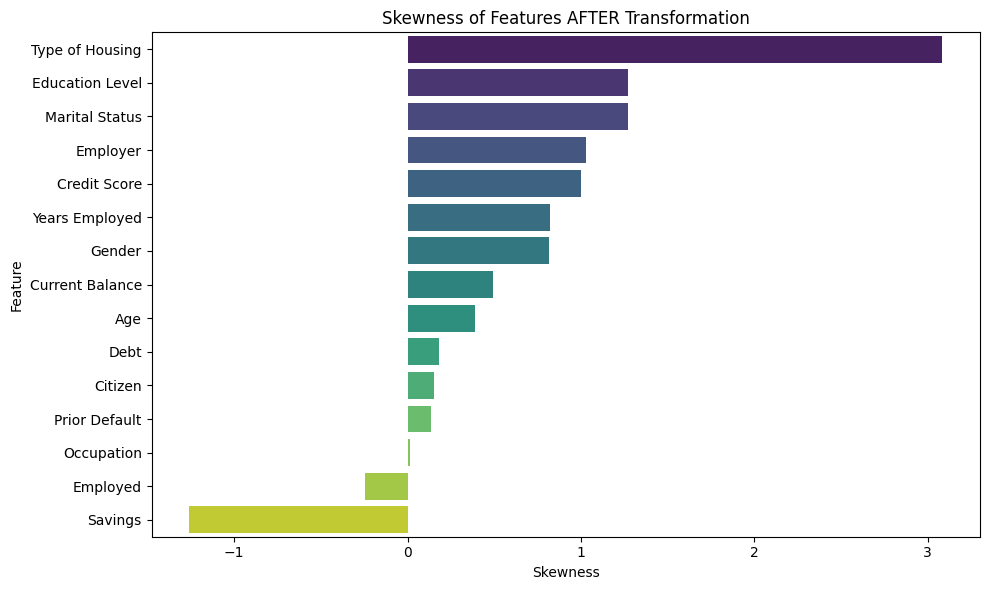

Skewness comparison for transformed features:
                 Before Skewness  After Skewness
Current Balance           13.340           0.494
Credit Score               5.037           1.002
Type of Housing            3.284           3.084
Years Employed             2.909           0.820
Savings                    2.728          -1.259
Employer                   2.339           1.031
Debt                       1.479           0.180
Marital Status             1.337           1.272
Education Level            1.337           1.272
Age                        1.077           0.388


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew
import pandas as pd

# Define reusable plot function
def plot_feature_distributions(data, title_prefix=''):
    plt.figure(figsize=(20, 12))
    for i, col in enumerate(data.columns):
        plt.subplot(4, 4, i + 1)
        sns.histplot(data[col], kde=True, bins=30, color='skyblue')
        plt.title(f"{title_prefix}{col}")
    plt.tight_layout()
    plt.show()

# Plot BEFORE transformation
print("Plotting feature distributions BEFORE transformation...")
plot_feature_distributions(X, title_prefix='Before: ')

# Calculate skewness before transformation
skew_vals_before = X.apply(lambda x: skew(x.dropna()))
skew_df_before = pd.DataFrame({'Feature': skew_vals_before.index, 'Skewness': skew_vals_before.values})
skew_df_before = skew_df_before.sort_values(by='Skewness', ascending=False)

# Barplot of skewness before transformation
plt.figure(figsize=(10, 6))
sns.barplot(data=skew_df_before, x='Skewness', y='Feature', palette='coolwarm')
plt.title('Skewness of Features BEFORE Transformation')
plt.tight_layout()
plt.show()

# Apply log1p to highly skewed features
high_skew = skew_df_before[skew_df_before['Skewness'] > 1]['Feature']
X_transformed = X.copy()
X_transformed[high_skew] = X_transformed[high_skew].apply(lambda x: np.log1p(x))

# Plot AFTER transformation
print("Plotting feature distributions AFTER transformation...")
plot_feature_distributions(X_transformed, title_prefix='After: ')

# Skewness after transformation
skew_vals_after = X_transformed.apply(lambda x: skew(x.dropna()))
skew_df_after = pd.DataFrame({'Feature': skew_vals_after.index, 'Skewness': skew_vals_after.values})
skew_df_after = skew_df_after.sort_values(by='Skewness', ascending=False)

# Barplot of skewness after transformation
plt.figure(figsize=(10, 6))
sns.barplot(data=skew_df_after, x='Skewness', y='Feature', palette='viridis')
plt.title('Skewness of Features AFTER Transformation')
plt.tight_layout()
plt.show()

# Comparison Table
comparison = pd.DataFrame({
    'Before Skewness': skew_vals_before,
    'After Skewness': skew_vals_after
}).loc[high_skew].sort_values(by='Before Skewness', ascending=False)

print("Skewness comparison for transformed features:")
print(comparison.round(3))


### Checking Outliers

In [8]:
# Z-score method (numerical features)
from scipy.stats import zscore
z_scores = np.abs(zscore(X))
outliers = (z_scores > 3).sum()
print("Outlier count per feature:\n", pd.Series(outliers, index=X.columns))

Outlier count per feature:
 Gender              0
Age                 7
Debt               10
Marital Status      2
Education Level     2
Occupation          0
Employer           12
Years Employed     21
Prior Default       0
Employed            0
Credit Score        6
Citizen             0
Type of Housing    55
Savings             7
Current Balance     5
dtype: int64


### Handling Outliers

In [9]:
def cap_outliers_iqr(df, cols):
    capped_df = df.copy()
    for col in cols:
        Q1 = capped_df[col].quantile(0.25)
        Q3 = capped_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        capped_df[col] = np.where(capped_df[col] < lower, lower,
                                  np.where(capped_df[col] > upper, upper, capped_df[col]))
    return capped_df

# Apply to all numeric columns
X = cap_outliers_iqr(X, X.select_dtypes(include=np.number).columns)


In [10]:
from scipy.stats import zscore
z_scores = np.abs(zscore(X))
outliers = (z_scores > 3).sum()
print("Outlier count per feature:\n", pd.Series(outliers, index=X.columns))

Outlier count per feature:
 Gender             0
Age                0
Debt               0
Marital Status     0
Education Level    0
Occupation         0
Employer           0
Years Employed     0
Prior Default      0
Employed           0
Credit Score       0
Citizen            0
Type of Housing    0
Savings            0
Current Balance    0
dtype: int64


### Target Class Distribution AND Correlation Heatmap for Features

- Visualizing class distribution to check for imbalance in the target variable
- Plotting correlation heatmap to identify relationships and multicollinearity between features

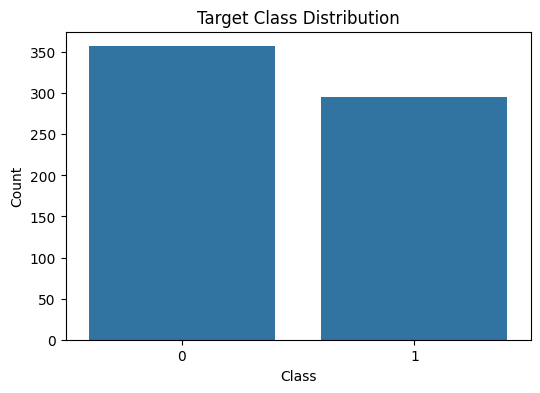

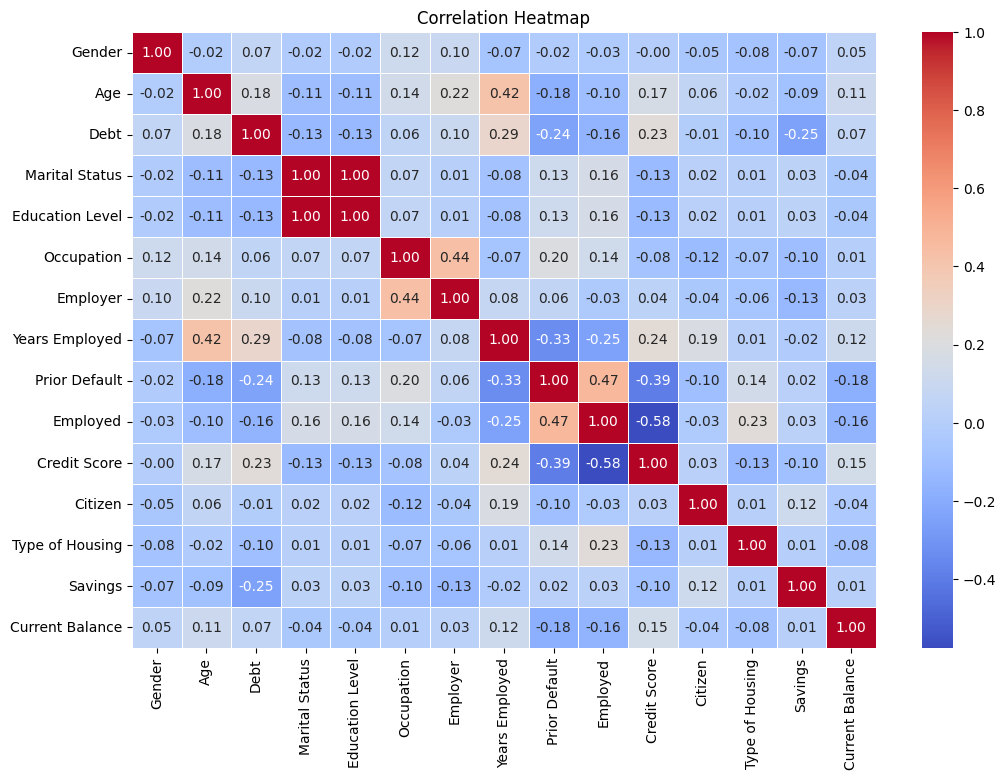

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Target Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Target Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# Step 2: Correlation Heatmap for features
# Calculate the correlation matrix
corr_matrix = X_train.corr()  # Using training data to avoid data leakage

# Create a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


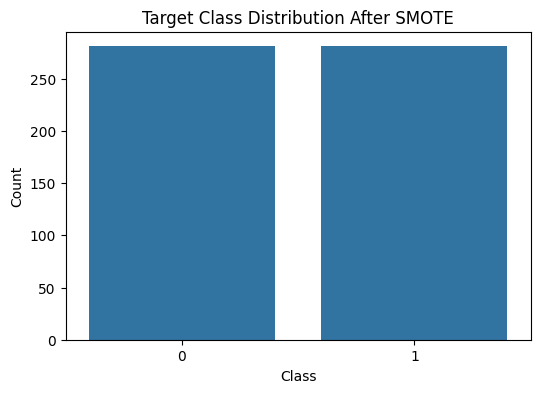

In [12]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only to the training data (NOT the test set!)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_smote)
plt.title('Target Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# Model Building


## Support Vector Machine (SVM)
## Baseline Model

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.97      0.79        76
           1       0.90      0.33      0.48        55

    accuracy                           0.70       131
   macro avg       0.78      0.65      0.64       131
weighted avg       0.76      0.70      0.66       131

SVM Confusion Matrix:
 [[74  2]
 [37 18]]
SVM Accuracy: 0.7022900763358778
SVM Precision: 0.9
SVM Recall: 0.32727272727272727
SVM F1 Score: 0.48
SVM ROC-AUC Score: 0.700956937799043


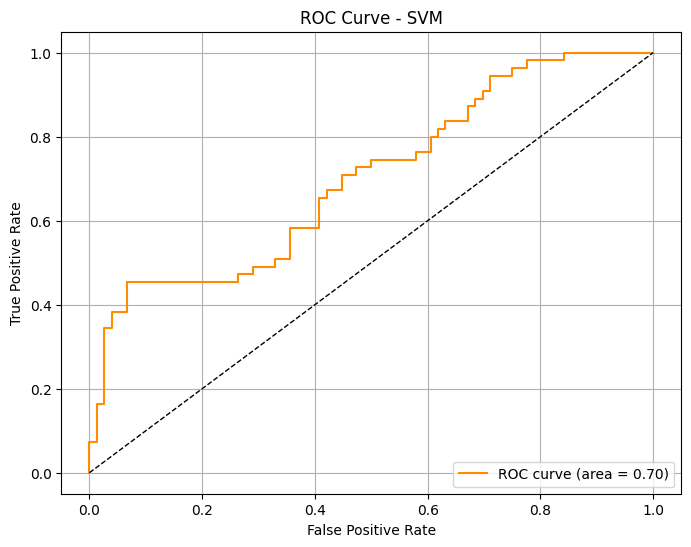

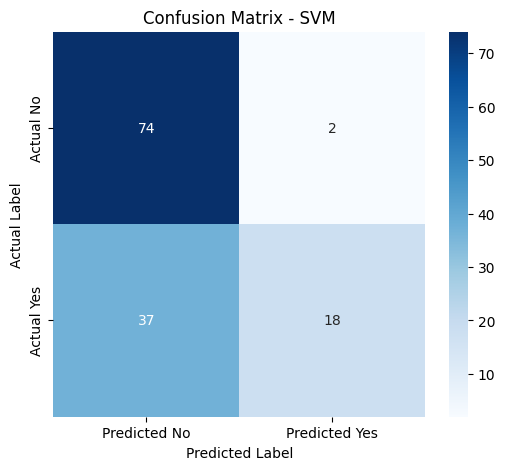

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import roc_curve


# Train a baseline SVM classifier (with probability estimation enabled)
svm_clf = SVC(random_state=42, probability=True)  # Enable probability estimation
svm_clf.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm_clf.predict(X_test)
y_pred_proba_svm = svm_clf.predict_proba(X_test)[:, 1]  # For ROC-AUC

# Evaluation
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))
print("SVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

# Additional metrics
accuracy = accuracy_score(y_test, y_pred_svm)
recall = recall_score(y_test, y_pred_svm)
precision = precision_score(y_test, y_pred_svm)
f1 = f1_score(y_test, y_pred_svm)

print(f"SVM Accuracy: {accuracy}")
print(f"SVM Precision: {precision}")
print(f"SVM Recall: {recall}")
print(f"SVM F1 Score: {f1}")

# ROC-AUC Score
print("SVM ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_svm))



# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_svm)
roc_auc = roc_auc_score(y_test, y_pred_proba_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()



cm = confusion_matrix(y_test, y_pred_svm)

# Confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix - SVM')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()



## Support Vector Machine (SVM)
## Hyperparameter Tuning
Using Grid search, StratifiedKFold cross-validation, Parallelisation.

Training Time: 1283.6851 seconds
Best Parameters:
 {'C': 0.1, 'kernel': 'linear'}
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.78      0.85        76
           1       0.75      0.93      0.83        55

    accuracy                           0.84       131
   macro avg       0.84      0.85      0.84       131
weighted avg       0.86      0.84      0.84       131

Confusion Matrix:
 [[59 17]
 [ 4 51]]
Accuracy:  0.8397
Precision: 0.7500
Recall:    0.9273
F1 Score:  0.8293
ROC-AUC Score: 0.700956937799043


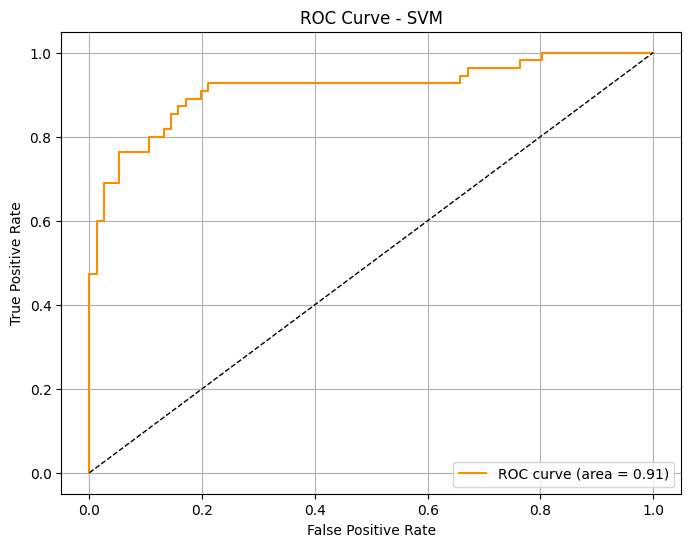

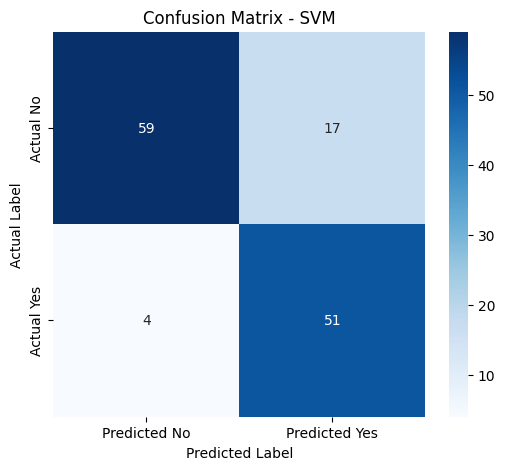

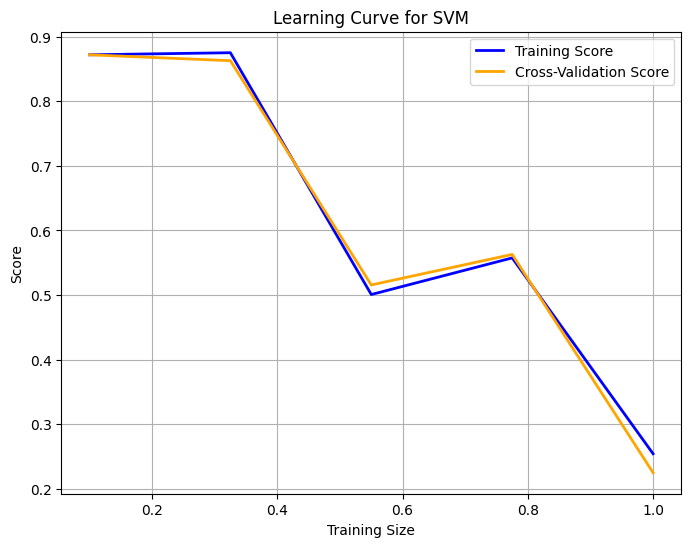

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import time
import numpy as np

# Define parameter grid
param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1]},
    {'kernel': ['rbf'], 'C': [1, 10], 'gamma': ['scale']},
    {'kernel': ['poly'], 'C': [1], 'degree': [3], 'gamma': ['scale']}
]

# GridSearch with Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_svm = GridSearchCV(SVC(probability=True, class_weight='balanced', random_state=42), param_grid, cv=cv, scoring='f1', n_jobs=-1, return_train_score=True)

# Start timing the training process
start_time = time.time()

# Fit the model with GridSearch
grid_svm.fit(X_train, y_train)

# End timing the training process
end_time = time.time()
training_time = end_time - start_time
print(f"Training Time: {training_time:.4f} seconds")

# Best model and evaluation
best_svm = grid_svm.best_estimator_

print("Best Parameters:\n", grid_svm.best_params_)

# Evaluate best SVM model
y_pred_svm = best_svm.predict(X_test)
y_proba_svm = best_svm.predict_proba(X_test)[:, 1]

# Classification report & confusion matrix
print("Classification Report:\n", classification_report(y_test, y_pred_svm))
cm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n", cm)

# Additional metrics
accuracy = accuracy_score(y_test, y_pred_svm)
precision = precision_score(y_test, y_pred_svm)
recall = recall_score(y_test, y_pred_svm)
f1 = f1_score(y_test, y_pred_svm)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# ROC-AUC Score
print("ROC-AUC Score:", roc_auc)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_svm)
roc_auc = roc_auc_score(y_test, y_proba_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix - SVM')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


# Learning Curve (using saved results from GridSearch)
train_sizes = grid_svm.cv_results_['mean_train_score']
test_sizes = grid_svm.cv_results_['mean_test_score']
train_sizes_filled = np.linspace(0.1, 1.0, len(train_sizes))  # Ensure correct x-axis values

# Plot learning curve without recalculating
plt.figure(figsize=(8, 6))
plt.plot(train_sizes_filled, train_sizes, label="Training Score", color="blue", linewidth=2)
plt.plot(train_sizes_filled, test_sizes, label="Cross-Validation Score", color="orange", linewidth=2)
plt.title('Learning Curve for SVM')
plt.xlabel('Training Size')
plt.ylabel('Score')
plt.legend(loc="best")
plt.grid(True)
plt.show()


### Understanding Feature Contributions to the Model using LIME


In [16]:
! pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=c2b8b9a11cebb4f7ab9cab74b293e625d9aa03e3b34431c5b89980650a27ab0c
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
import lime
import lime.lime_tabular

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=['No', 'Yes'],
    mode='classification'
)

# Pick one instance to explain
i = 10
exp = explainer.explain_instance(X_test.iloc[i].values, best_svm.predict_proba, num_features=10)
exp.show_in_notebook(show_table=True)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


# Multilayer Perceptron (MLP)
## Baseline


Iteration 1, loss = 6.40229268
Iteration 2, loss = 3.39185358
Iteration 3, loss = 2.93982794
Iteration 4, loss = 3.25261354
Iteration 5, loss = 2.73390205
Iteration 6, loss = 2.16303033
Iteration 7, loss = 1.96938461
Iteration 8, loss = 1.68301971
Iteration 9, loss = 1.71878214
Iteration 10, loss = 1.70907939
Iteration 11, loss = 1.33093096
Iteration 12, loss = 1.28957761
Iteration 13, loss = 1.27025573
Iteration 14, loss = 0.86365213
Iteration 15, loss = 1.31868389
Iteration 16, loss = 1.27508206
Iteration 17, loss = 1.26908477
Iteration 18, loss = 0.93599626
Iteration 19, loss = 0.84242215
Iteration 20, loss = 1.20932826
Iteration 21, loss = 1.44043007
Iteration 22, loss = 1.35039151
Iteration 23, loss = 0.94111403
Iteration 24, loss = 0.95044638
Iteration 25, loss = 0.78879593
Iteration 26, loss = 0.90348000
Iteration 27, loss = 0.84756472
Iteration 28, loss = 0.74656821
Iteration 29, loss = 0.68365405
Iteration 30, loss = 0.62721753
Iteration 31, loss = 0.61993188
Iteration 32, los

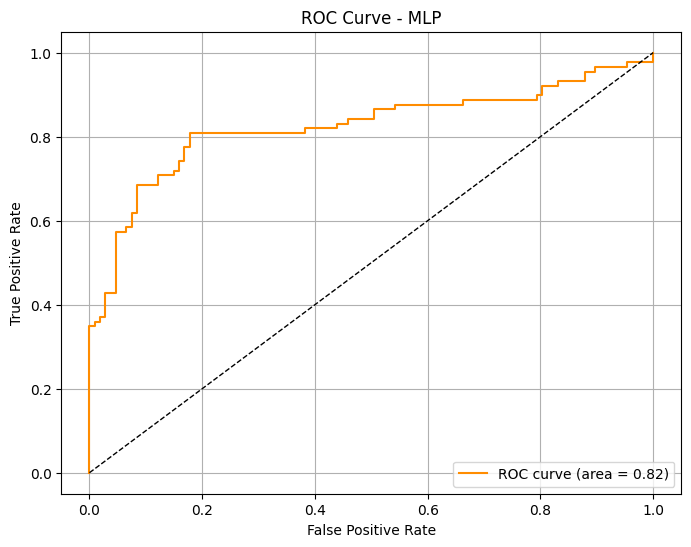

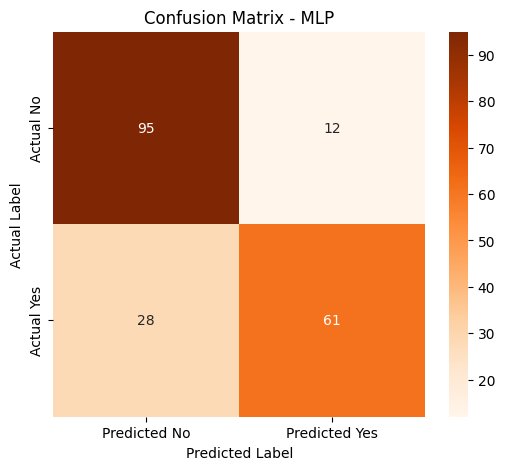

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.neural_network import MLPClassifier

# Train MLP model with verbose=1 to show training progress (epoch-wise)
mlp_clf = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                        alpha=0.001, max_iter=200, random_state=42, verbose=1)
mlp_clf.fit(X_train, y_train)

# Predictions
y_pred_mlp = mlp_clf.predict(X_test)
y_pred_proba_mlp = mlp_clf.predict_proba(X_test)[:,1]

# Print Classification Report
print("MLP Classification Report:\n", classification_report(y_test, y_pred_mlp))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_mlp)
print("MLP Confusion Matrix:\n", cm)

# ROC AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba_mlp)
print("MLP ROC-AUC Score:", roc_auc)

# Additional metrics
accuracy = accuracy_score(y_test, y_pred_mlp)
precision = precision_score(y_test, y_pred_mlp)
recall = recall_score(y_test, y_pred_mlp)
f1 = f1_score(y_test, y_pred_mlp)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_mlp)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - MLP')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix - MLP')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


# Multilayer Perceptron (MLP)
## Hyperparameter Tuning
Using Grid search, StratifiedKFold cross-validation, Parallelisation.

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Training Time: 0.0001 seconds
Best hyperparameters: {'activation': 'logistic', 'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001, 'max_iter': 200, 'solver': 'adam'}
Best cross-validation ROC-AUC: 0.8817299828905245
MLP Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.89      0.88        76
           1       0.85      0.80      0.82        55

    accuracy                           0.85       131
   macro avg       0.85      0.85      0.85       131
weighted avg       0.85      0.85      0.85       131

MLP Confusion Matrix:
 [[68  8]
 [11 44]]
MLP ROC-AUC Score: 0.9119617224880382
Accuracy:  0.8550
Precision: 0.8462
Recall:    0.8000
F1 Score:  0.8224


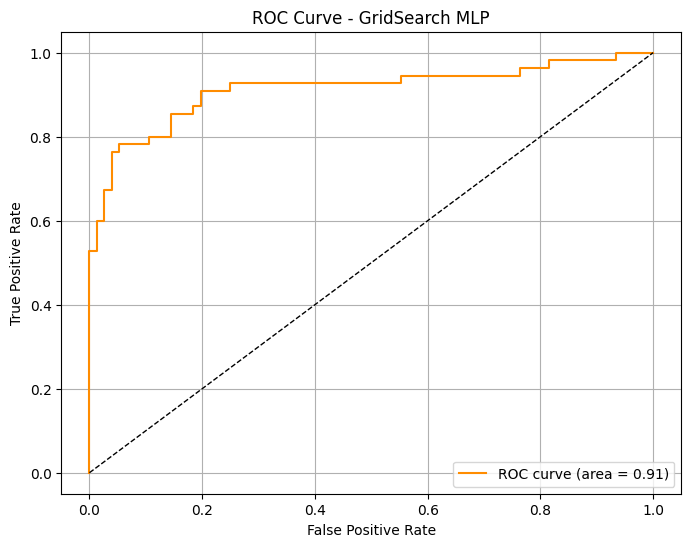

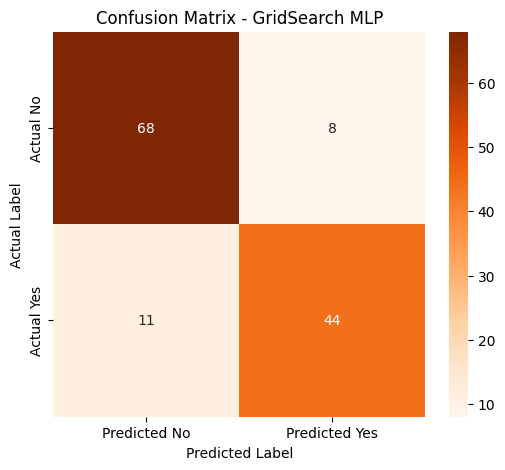

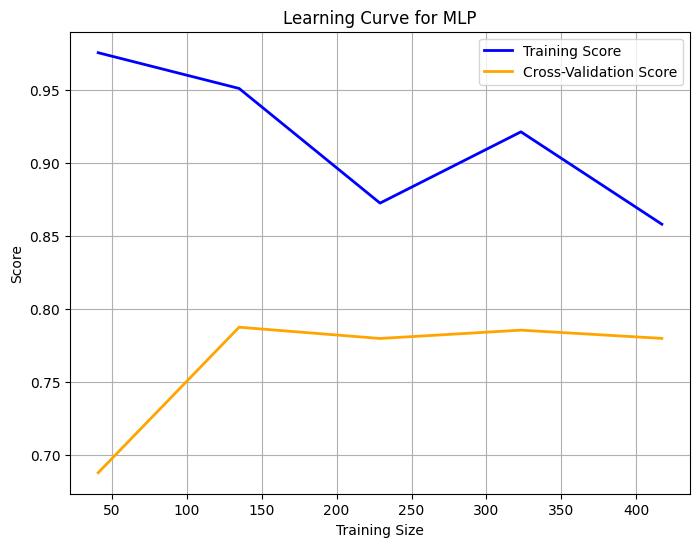

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import time

# Define the parameter grid for tuning
param_grid = {
    'hidden_layer_sizes': [(64,), (64, 32), (128, 64)],
    'activation': ['relu', 'tanh', 'logistic'],
    'alpha': [0.0001, 0.001],         # L2 regularization (weight decay)
    'learning_rate_init': [0.001, 0.01],
    'solver': ['adam', 'sgd'],
    'max_iter': [200]
}

# 5-fold stratified cross-validation for robust evaluation
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    MLPClassifier(random_state=42, verbose=0),  # Set verbose=1 for epoch-wise output
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    verbose=0,                 # Set verbose=2 for grid search output
    n_jobs=-1
)

# Fit the model
grid_search.fit(X_train, y_train)


start_time = time.time()

# End timing the training process
end_time = time.time()
training_time = end_time - start_time
print(f"Training Time: {training_time:.4f} seconds")

# Best params and score
print("Best hyperparameters:", grid_search.best_params_)
print("Best cross-validation ROC-AUC:", grid_search.best_score_)

# Get the best model from grid search
best_mlp = grid_search.best_estimator_

# Predict on the test set
y_pred = best_mlp.predict(X_test)
y_proba = best_mlp.predict_proba(X_test)[:, 1]

# Print Classification Report
print("MLP Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("MLP Confusion Matrix:\n", cm)

# ROC AUC Score
roc_auc = roc_auc_score(y_test, y_proba)
print("MLP ROC-AUC Score:", roc_auc)

# Additional metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - GridSearch MLP')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix - GridSearch MLP')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()




from sklearn.model_selection import learning_curve

# Learning Curve for the best MLP model
train_sizes, train_scores, test_scores = learning_curve(
    best_mlp, X_train, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Plot Learning Curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training Score", color="blue", linewidth=2)
plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Cross-Validation Score", color="orange", linewidth=2)
plt.title('Learning Curve for MLP')
plt.xlabel('Training Size')
plt.ylabel('Score')
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [17]:
  # --- LIME Explanation for Understanding Feature Contributions (Local Explanation) ---
  import lime
  import lime.lime_tabular

  explainer = lime.lime_tabular.LimeTabularExplainer(
      training_data=X_train.values,
      feature_names=X_train.columns,
      class_names=['No', 'Yes'],
      mode='classification'
  )

  # Explain one instance (e.g., the 10th sample) using LIME
  i = 10
  exp = explainer.explain_instance(X_test.iloc[i].values, best_mlp.predict_proba, num_features=10)
  exp.show_in_notebook(show_table=True)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


# Comparison Between Support Vector Machine (SVM) & Multilayer Perceptron (MLP)

In [ ]:
import pandas as pd

# Data for comparison
data = {
    'Model': ['SVM', 'MLP'],
    'Best Parameters': [
        {'C': 0.1, 'kernel': 'linear'},
        {'activation': 'logistic', 'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001, 'max_iter': 200, 'solver': 'adam'}
    ],
    'Accuracy': [0.8397, 0.8550],
    'Precision': [0.7500, 0.8462],
    'Recall': [0.9273, 0.8000],
    'F1 Score': [0.8293, 0.8224],
    'ROC-AUC Score': [0.9146, 0.9120],
}

# Create DataFrame
results_df = pd.DataFrame(data)

# Display the results
print(results_df)


  Model                                    Best Parameters  Accuracy  \
0   SVM                     {'C': 0.1, 'kernel': 'linear'}    0.8397   
1   MLP  {'activation': 'logistic', 'alpha': 0.0001, 'h...    0.8550   

   Precision  Recall  F1 Score  ROC-AUC Score  
0     0.7500  0.9273    0.8293         0.9146  
1     0.8462  0.8000    0.8224         0.9120  


# Confusion Matrix

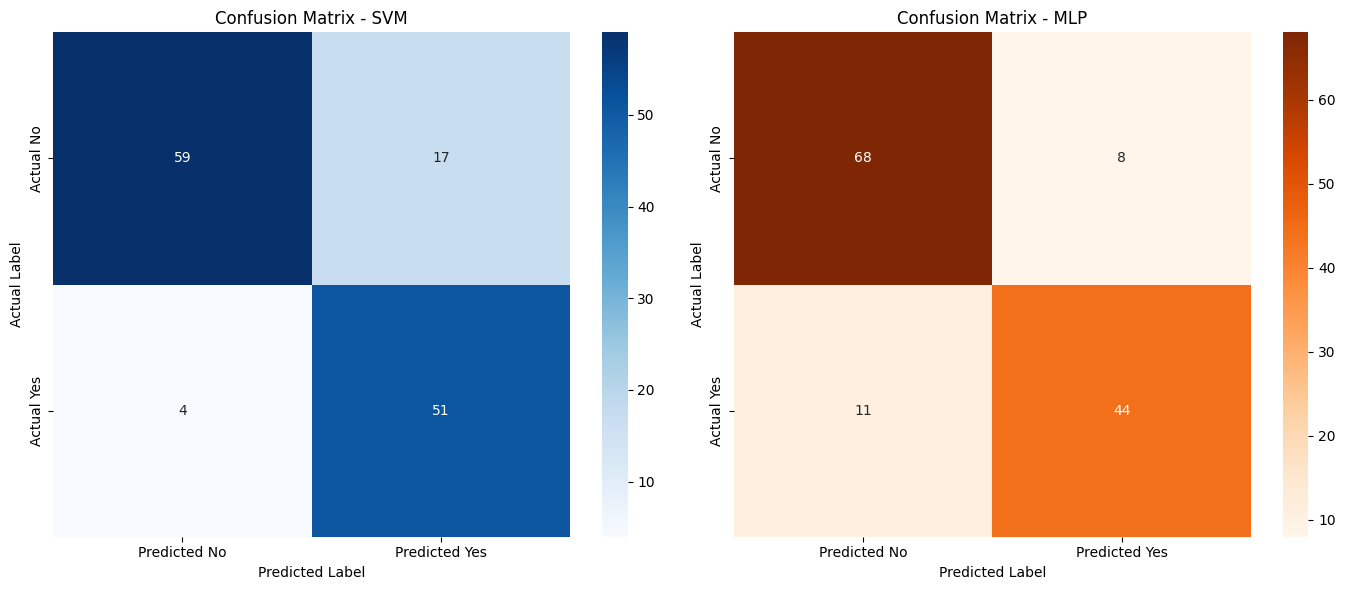

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Confusion matrices for SVM and MLP
cm_svm = np.array([[59, 17], [4, 51]])
cm_mlp = np.array([[68, 8], [11, 44]])

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# SVM Confusion Matrix
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted No', 'Predicted Yes'], yticklabels=['Actual No', 'Actual Yes'], ax=axes[0])
axes[0].set_title('Confusion Matrix - SVM')
axes[0].set_xlaabel('Predicted Label')
axes[0].set_ylabel('Actual Label')

# MLP Confusion Matrix
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Oranges', xticklabels=['Predicted No', 'Predicted Yes'], yticklabels=['Actual No', 'Actual Yes'], ax=axes[1])
axes[1].set_title('Confusion Matrix - MLP')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('Actual Label')

plt.tight_layout()
plt.show()


ROC-AUC Curve

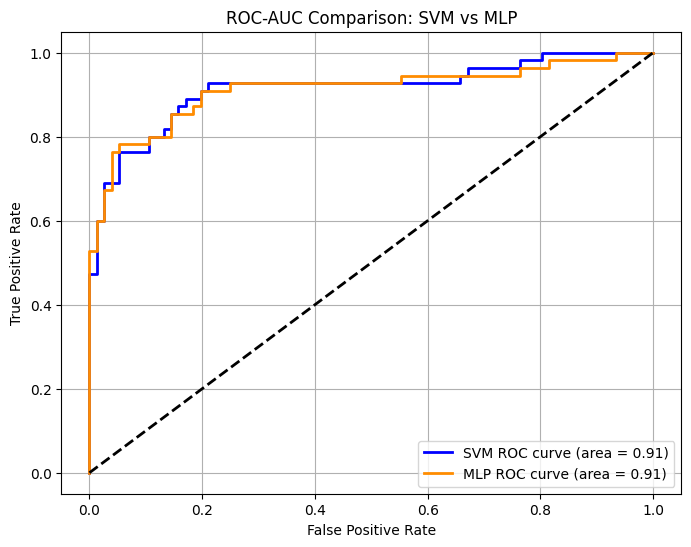

In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# SVM ROC Curve
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_proba_svm)
roc_auc_svm = roc_auc_score(y_test, y_proba_svm)

# MLP ROC Curve
fpr_mlp, tpr_mlp, thresholds_mlp = roc_curve(y_test, y_proba)
roc_auc_mlp = roc_auc_score(y_test, y_proba)

# Plot ROC-AUC Comparison
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, color='blue', lw=2, label='SVM ROC curve (area = %0.2f)' % roc_auc_svm)
plt.plot(fpr_mlp, tpr_mlp, color='darkorange', lw=2, label='MLP ROC curve (area = %0.2f)' % roc_auc_mlp)
plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line representing random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Comparison: SVM vs MLP')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


## Comparison of all metrics ('Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC Score) for SVM and MLP

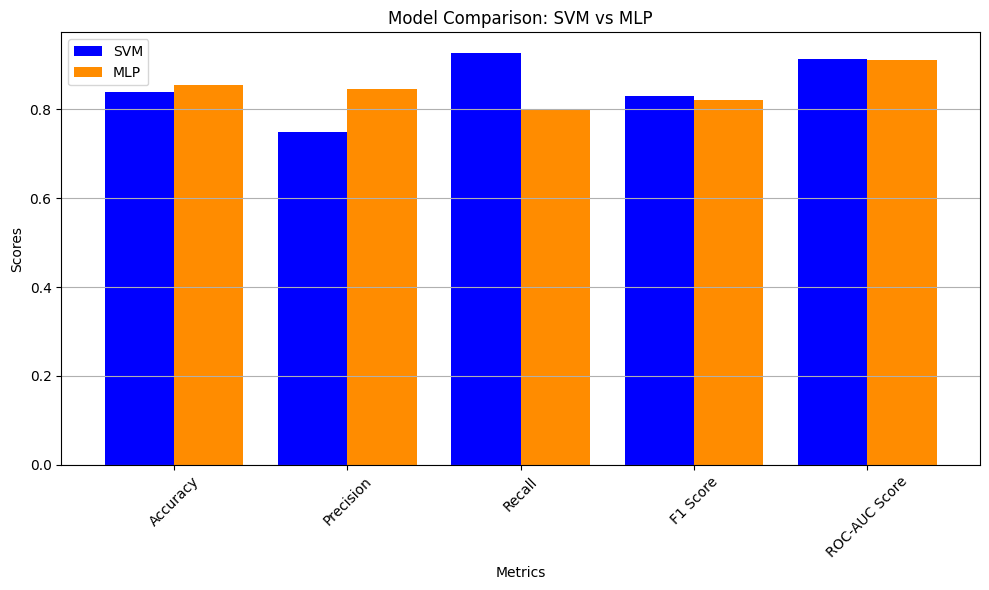

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Prepare data for bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC Score']
svm_metrics = [0.8397, 0.7500, 0.9273, 0.8293, 0.9146]
mlp_metrics = [0.8550, 0.8462, 0.8000, 0.8224, 0.9120]

# Create DataFrame
metrics_df = pd.DataFrame({
    'Metric': metrics,
    'SVM': svm_metrics,
    'MLP': mlp_metrics
})

# Plotting
ax = metrics_df.set_index('Metric').plot(kind='bar', figsize=(10, 6), width=0.8, color=['blue', 'darkorange'])
plt.title('Model Comparison: SVM vs MLP')
plt.ylabel('Scores')
plt.xlabel('Metrics')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


# Saving the Best Model


In [ ]:
import joblib

# Save the best SVM model
joblib.dump(best_svm, 'best_svm_model.pkl')



['best_svm_model.pkl']

In [ ]:
# Save the best MLP model
joblib.dump(best_mlp, 'best_mlp_model.pkl')

['best_mlp_model.pkl']

In [ ]:
# Combine X_test and y_test into a single DataFrame
test_data = X_test.copy()
test_data['Approval'] = y_test.values

# Save to CSV
test_data.to_csv('test_data.csv', index=False)
